## Overview: Model Selection, Model 1
In this notebook we implement the first analytical model. Model 1 focusses on providing two perspectives of the resolution time for tickets in Q2 2016. The first perspective visualizes the resolution times of ticket activity in Q2 2016 with a violin plot. The second plot that is a probablistic perspective. It computes the cumulative density (empirical) function of the resolution time. The observations from this modelling activity are:
1. Resolution time clusters into five groups. A large group of tickets that are resolved fairly quickly and four groups of varying, but larger resolution times.
2. About 80% of the tickets are resolved within 1000 hours. The other 20 percent are associated with longer resolution time. Identifying if ticket resolution will fall into this long tail was done in https://doi.org/10.1016/j.mlwa.2021.100237
3. There are no assumptions or choices that have to be made to develop these models, so there are no model choice observations

In [1]:
from importlib.resources import files
import pandas as pd
import plotly.express as px
import numpy as np
fp = str(files("kmds.examples").joinpath("example_analytics_post_data_rep1_data.csv"))

In [2]:
df = pd.read_csv(fp)

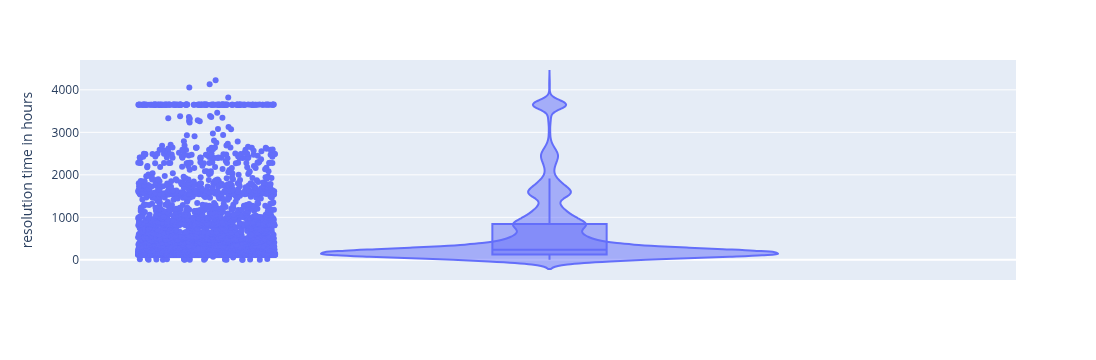

In [3]:
fig = px.violin(df, y="resolution_time",
                box=True, points="all",
                labels=dict(resolution_time="resolution time in hours"),
                hover_data=df.columns)
fig.show()

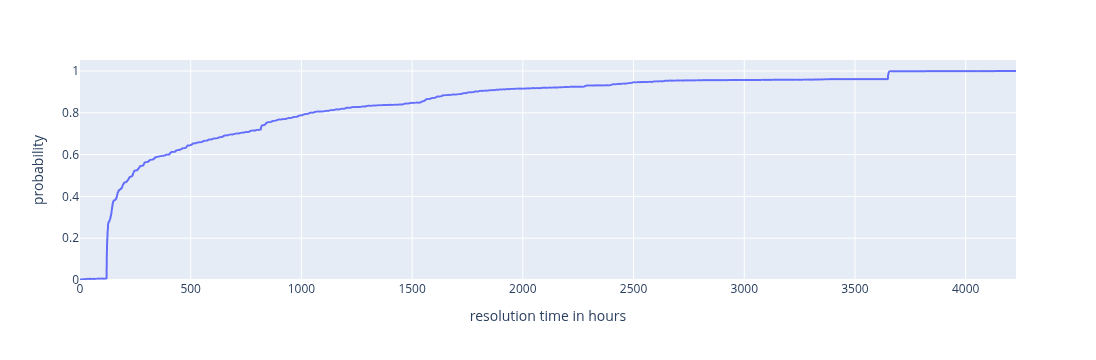

In [4]:
import plotly.express as px
fig = px.ecdf(df, x="resolution_time", labels=dict(resolution_time="resolution time in hours"))
fig.show()

In [5]:
from kmds.tagging.tag_types import ModelSelectionTags
from owlready2 import *
from utils.load_utils import *
#from utils.path_utils import *
KNOWLEDGE_BASE = str(files("kmds.examples").joinpath("example_analytics_kb_app_workflow.xml"))

ModuleNotFoundError: No module named 'tagging'

In [ ]:
onto2 = load_kb(KNOWLEDGE_BASE)

In [ ]:
with onto2:
    insts = Workflow.instances()
the_workflow_instance = insts[0]

In [ ]:
insts

In [ ]:
ms_obs_list = []
observation_count = 1

ms1 = ModelSelectionObservation(namespace=onto2)
ms1.finding = "Resolution time clusters into five groups. A large group of tickets that are resolved fairly\
quickly and four groups of varying, but larger resolution times."
ms1.finding_sequence = observation_count
ms1.model_selection_observation_type = ModelSelectionTags.MODEL_SELECTION_OBSERVATION.value
ms_obs_list.append(ms1)
observation_count += 1

ms2 = ModelSelectionObservation(namespace=onto2)
ms2.finding = "About 80% of the tickets are resolved within 1000 hours. The other 20 percent are associated with longer\
resolution time. Identifying if ticket resolution will fall into this long tail was done in https://doi.org/10.1016/j.mlwa.2021.100237"
ms2.finding_sequence = observation_count
ms2.model_selection_observation_type = ModelSelectionTags.MODEL_SELECTION_OBSERVATION.value
ms_obs_list.append(ms2)


observation_count += 1
ms3 = ModelSelectionObservation(namespace=onto2)
ms3.finding = "There are no assumptions or choices that have to be made to develop these models,\
so there are no model choice observations"
ms3.finding_sequence = observation_count
ms3.model_selection_observation_type = ModelSelectionTags.MODEL_SELECTION_OBSERVATION.value
ms_obs_list.append(ms3)



the_workflow_instance.has_model_selection_observations = ms_obs_list

onto2.save(file=KNOWLEDGE_BASE, format="rdfxml")